In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

fig_save_path = "/Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/AR_plots_new/"

In [2]:
cd ..

/Users/thomassainsbury/Documents/Mathis_lab/Mathis_lab_code/FreelyMovingVR4Mice/dj_pipeline


In [3]:
%run env.py
%run run.py connect

2024-08-23 07:47:57,569::INFO::settings.py::Setting loglevel to INFO
2024-08-23 07:47:57,570::INFO::settings.py::Setting stores to {}
2024-08-23 07:47:57,570::INFO::settings.py::Setting database.misc.schema_prefix to 
2024-08-23 07:47:57,571::INFO::settings.py::Setting database.misc.create_tables to True
2024-08-23 07:47:57,571::INFO::settings.py::Setting enable_python_native_blobs to True
2024-08-23 07:47:57,571::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2024-08-23 07:47:57,572::INFO::settings.py::Setting database.user to thomas
2024-08-23 07:47:57,572::INFO::settings.py::Setting database.password to thomas


Connecting thomas@128.178.51.167:3309


2024-08-23 07:47:58,190::INFO::connection.py::Connected thomas@128.178.51.167:3309
2024-08-23 07:47:58,628::INFO::table.py::could not log event in table ~log
2024-08-23 07:48:00,491::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema import vr4mice, dlc, base_analysis
import vr4mice.analysis.plotting as plotting
import vr4mice.analysis.utils as utils
import vr4mice.analysis.visual_discrim_functions as vdf
vdf.get_rc_params()

In [5]:
base_analysis.DataFrame().fetch("dataset")

array(['Jacana_2024-07-26_1', 'Jacana_2024-07-27_1',
       'Jacana_2024-07-28_1', 'Jacana_2024-07-29_2',
       'Jacana_2024-07-30_1', 'Jacana_2024-07-31_1',
       'Jacana_2024-08-01_1', 'Jacana_2024-08-02_1',
       'Jacana_2024-08-05_2', 'Jacana_2024-08-06_1',
       'Jacana_2024-08-07_1', 'Jacana_2024-08-08_2',
       'Jacana_2024-08-09_1', 'Jacana_2024-08-10_1',
       'Jacana_2024-08-11_1', 'Jacana_2024-08-12_1',
       'Jacana_2024-08-13_1', 'Jacana_2024-08-14_1',
       'Jacana_2024-08-15_1', 'Jacana_2024-08-16_1',
       'Jacana_2024-08-19_1', 'Jacana_2024-08-20_1',
       'Jacana_2024-08-21_1', 'Jacana_2024-08-22_1', 'Kiwi_2024-07-26_1',
       'Kiwi_2024-07-27_1', 'Kiwi_2024-07-28_1', 'Kiwi_2024-07-29_1',
       'Kiwi_2024-07-30_1', 'Kiwi_2024-07-31_1', 'Kiwi_2024-08-01_1',
       'Kiwi_2024-08-02_1', 'Kiwi_2024-08-05_1', 'Kiwi_2024-08-06_1',
       'Kiwi_2024-08-07_1', 'Kiwi_2024-08-08_1', 'Kiwi_2024-08-08_3',
       'Kiwi_2024-08-09_1', 'Kiwi_2024-08-10_2', 'Kiwi_2024-08-

In [6]:
dual_occuder = [{"dataset": "Nightingale_2024-08-14_1"},
                {"dataset": "Nightingale_2024-08-13_1"},
                {"dataset": "Nightingale_2024-08-12_1"},
                {"dataset": "Nightingale_2024-08-11_1"},
                {"dataset": "Nightingale_2024-08-10_1"},
                {"dataset": "Lemming_2024-08-13_1"},
                {"dataset": "Lemming_2024-08-12_1"},
                {"dataset": "Lemming_2024-08-11_1"},
                {"dataset": "Lemming_2024-08-10_1"},
                {"dataset": "Jacana_2024-08-13_1"},
                {"dataset": "Jacana_2024-08-14_1"},
                {"dataset": "Jacana_2024-08-15_1"},
                {"dataset": "Jacana_2024-08-16_1"},
                {"dataset": "Jacana_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-10_2"},
                {"dataset": "Kiwi_2024-08-11_4"},
                {"dataset": "Kiwi_2024-08-12_2"},
                {"dataset": "Kiwi_2024-08-13_1"},
                {"dataset": "Kiwi_2024-08-14_1"},
                {"dataset": "Oribi_2024-08-16_1"},
                {"dataset": "Oribi_2024-08-19_1"},
                {"dataset": "Oribi_2024-08-20_1"},
                {"dataset": "Oribi_2024-08-21_1"},
                {"dataset": "Oribi_2024-08-22_1"},
                {"dataset": "Pheasant_2024-08-15_2"},
                {"dataset": "Pheasant_2024-08-16_1"},
                {"dataset": "Pheasant_2024-08-20_1"},
                {"dataset": "Pheasant_2024-08-21_1"},
               ]


   



In [7]:
def get_all_in_list(data_set_list, training_stage="dual_occluder"):
    print(training_stage)
    big_df = []
    day = 0
    for d in data_set_list:
        
        split_d = d["dataset"].split("_")
        print(split_d)
        df, box_df = base_analysis.DataFrame().get_data(key =  d)
        df ["mouse_name"] = split_d [0]
        df ["session"] = df ["dataset"]
        df ["date"] = split_d [1]
        df ["training_stage"] = training_stage
        big_df.append(df)
    big_df =  pd.concat(big_df).reset_index()
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max())
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)

    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max()
    )
    big_df["velocity"][big_df ["velocity"] > 300] = np.nan
    big_df["veloctiy"] =big_df["velocity"].interpolate().copy()
    return(big_df.reset_index(drop=True))

In [8]:
def get_j_shaped(big_df):
        # J-shaped trials
    j_shaped = big_df[
        (big_df.trial_duration <= 5) & (big_df.trial_rewarded > 0.5) & (big_df["trial_tortuosity"] <= 5)
    ]

    # stats: percentage of j shaped trials per session
    j_shaped_percentage = (
        j_shaped.groupby(["session"]).trial.nunique().values
        / big_df.groupby(["session"]).trial.nunique().values
    )
    print(j_shaped_percentage.mean(), stats.sem(j_shaped_percentage))
    return(j_shaped)

In [9]:
big_df = get_all_in_list(data_set_list = dual_occuder)


dual_occluder
['Nightingale', '2024-08-14', '1']
['Nightingale', '2024-08-13', '1']
['Nightingale', '2024-08-12', '1']
['Nightingale', '2024-08-11', '1']
['Nightingale', '2024-08-10', '1']
['Lemming', '2024-08-13', '1']
['Lemming', '2024-08-12', '1']
['Lemming', '2024-08-11', '1']
['Lemming', '2024-08-10', '1']
['Jacana', '2024-08-13', '1']
['Jacana', '2024-08-14', '1']
['Jacana', '2024-08-15', '1']
['Jacana', '2024-08-16', '1']
['Jacana', '2024-08-19', '1']
['Kiwi', '2024-08-10', '2']
['Kiwi', '2024-08-11', '4']
['Kiwi', '2024-08-12', '2']
['Kiwi', '2024-08-13', '1']
['Kiwi', '2024-08-14', '1']
['Oribi', '2024-08-16', '1']
['Oribi', '2024-08-19', '1']
['Oribi', '2024-08-20', '1']
['Oribi', '2024-08-21', '1']
['Oribi', '2024-08-22', '1']
['Pheasant', '2024-08-15', '2']
['Pheasant', '2024-08-16', '1']
['Pheasant', '2024-08-20', '1']
['Pheasant', '2024-08-21', '1']


/var/folders/xx/w02j3bzd5n549z3dmcg59ddw0000gn/T/ipykernel_37675/3113316428.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  big_df["velocity"][big_df ["velocity"] > 300] = np.nan


2024-08-23 07:50:40,570::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-08-23 07:50:40,575::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-08-23 07:50:40,602::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-08-23 07:50:40,604::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-08-23 07:50:40,671::INFO::category.py::Using categorical un

              mean       sem
aperture                    
12.0      0.860919  0.014092
4.3       0.796493  0.015558


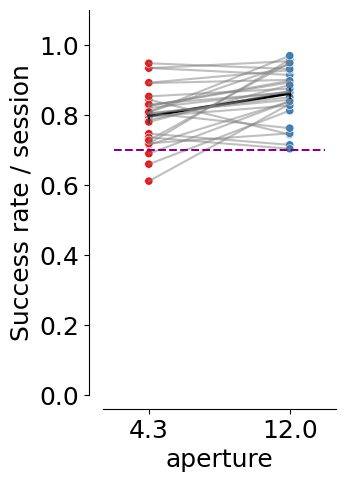

In [10]:
fig,ax = plt.subplots(1,1, figsize = (3,5))
plotting.plot_rewards(df=big_df, ax=ax, alpha=0.5, per_aperture=True)
plt.ylim(0,1.1)
sns.despine(offset=10)
plt.savefig(fig_save_path + "dual_occluder_rewards.svg", transparent=True)

In [11]:
j_shaped = get_j_shaped(big_df)

0.6690952049752615 0.015922265483501633


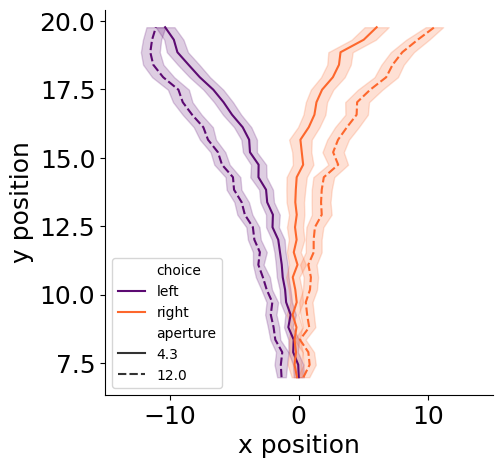

In [12]:
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")
mean_mouse = j_shaped.groupby(
    ["session", "choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only=True).copy()

fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x="bin_centers",
    y="x",
    hue="choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-15,15)
plt.savefig(fig_save_path + "dual_occluder_aperture_mean_traj.svg", transparent=True)

In [13]:
big_df.keys()

Index(['index', 'dataset', 'step', 'step_time', 'trial', 'reward', 'x', 'y',
       'bins_y', 'norm_y', 'mouse_can_report', 'iti', 'mouse_correct',
       'object_on_left', 'mouse_in_left', 'mouse_in_right', 'velocity',
       'velocity_x', 'velocity_y', 'acceleration_x', 'acceleration_y',
       'head_dir', 'trial_duration', 'distance', 'trial_traj_path_length',
       'trial_init_x', 'trial_init_y', 'trial_end_x', 'trial_end_y',
       'trial_rewarded', 'trial_direct_path', 'trial_tortuosity', 'trial_step',
       'trial_step_time', 'trial_step_fraction', 'choice', 'flip_one_side',
       'trial_right_choice', 'trial_left_choice', 'aperture', 'time',
       'time_elapsed', 'mouse_name', 'session', 'date', 'training_stage',
       'session_increment', 'veloctiy'],
      dtype='object')

In [14]:
columns = [
    "y",
   # "heading_dir",
    #"head_angle",
    "trial_tortuosity",
    "trial_init_x",
    "trial_duration",
    "x",
    #"norm_x",
    "trial_init_y",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "acceleration_x",
    #"heading_dir_velocity",
    "trial_traj_path_length",
    "trial_rewarded",
    #"heading_dir_acceleration",
    "norm_y",
    "flip_one_side",
   # "distance_to_reward",
]

interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=200, value_columns=["trial_left_choice"] + columns
)

interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["session", "trial"]
).trial.cumcount()
interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / 200

interpolated_j_shaped["velocity_x_fliped"] = (
    interpolated_j_shaped["velocity_x"] * interpolated_j_shaped["flip_one_side"]
)
#interpolated_j_shaped["head_dir_re"] = interpolated_j_shaped["heading_dir"] - 90

ValueError: `y` must contain only finite values.